# Lab 4.1 — Text Preprocessing
**Module 4: Applied Natural Language Processing**

In this lab you will:
- Build a realistic mock dataset of Nutanix support tickets
- Apply **tokenisation** to split text into individual tokens
- Remove **stop words** that carry no signal
- Compare **stemming** (PorterStemmer) vs **lemmatisation** (WordNetLemmatizer)
- Assemble a reusable `preprocess()` pipeline function
- Save the cleaned dataset for Lab 4.2

> **Instructor Note:** Raw text is noisy — punctuation, capitalisation, morphological variants (`failing`/`failed`/`failure`) all fragment the vocabulary. Preprocessing normalises the text so that downstream vectorisers see a consistent token space. This is the 90% of NLP that actually matters in production.

## 📦 Requirements & Troubleshooting

### Required Packages

| Package | Install Name | Notes |
|---------|-------------|-------|
| nltk | `nltk` | Also downloads `punkt`, `stopwords`, `wordnet`, `omw-1.4` data |
| pandas | `pandas` | |
| numpy | `numpy` | |
| matplotlib | `matplotlib` | |

**Install all at once:**
```bash
pip install nltk pandas numpy matplotlib
```

---

### ⚠️ Common Errors & Fixes

**`ModuleNotFoundError: No module named '...'`**
> Package is missing from the active Python environment.
> Fix: Run the pip install command above in a terminal, then **restart the kernel**.

**`CalledProcessError` — `--break-system-packages` / exit status 2**
> You are using a virtual environment (e.g. `myenv`) where that flag is not supported, or your pip version is old.
> Fix: Open a terminal, activate your venv (`source myenv/bin/activate`), then run `pip install <package>` without that flag.

**`LookupError: Resource punkt not found` / NLTK data errors**
> NLTK language data wasn't downloaded.
> Fix: Run `import nltk; nltk.download('all')` in a notebook cell, or run `python -m nltk.downloader punkt stopwords wordnet omw-1.4` in a terminal.

**`Failed building wheel for <package>` / C extension errors**
> The package does not support your Python version (most common on Python 3.14).
> Fix: Switch the kernel to **Python 3.13**. Click the kernel name in the VS Code top-right corner → *Select Another Kernel* → *Python 3.13*. Then re-run.

**Packages install with no error but `ModuleNotFoundError` still appears**
> You installed into a different Python than the one the notebook is using.
> Fix: Check the kernel shown in the top-right of VS Code. Open a terminal, activate that environment, and install packages there.

**`PermissionError` or `[Errno 13]` when installing**
> Trying to install into a read-only system Python.
> Fix: Use a virtual environment — `python -m venv myenv && source myenv/bin/activate` — then install.

In [1]:
import subprocess, sys

required = {
    'nltk': 'nltk',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
}
for pkg, inst in required.items():
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', inst, '--quiet', '--break-system-packages'])

import nltk
for resource in ['punkt', 'punkt_tab', 'stopwords', 'wordnet', 'omw-1.4']:
    nltk.download(resource, quiet=True)

print('All packages ready ✅')

All packages ready ✅


## 1. The Raw Data — Mock Nutanix Support Tickets

We generate 60 mock support tickets across 6 categories that Nutanix L1/L2 engineers would route daily.

| Category | Description |
|----------|-------------|
| `storage` | Stargate, disk I/O, NFS datastore, tier migration |
| `network` | NIC, OVS, LACP, BGP, VLAN, MTU |
| `compute` | AHV, CVM memory, live migration, vCPU |
| `prism` | Prism Central/Element UI, REST API, RBAC, alerts |
| `replication` | Cerebro, DR, snapshots, NearSync, metro |
| `performance` | Latency, IOPS, cache hit ratio, throughput |

> **Instructor Note:** In a real NLP project the dataset comes from a ticketing system like ServiceNow or Jira. We generate it here to keep the lab self-contained, but every technique below applies directly to exported CSV data from those systems.

In [2]:
import pandas as pd
import numpy as np

raw_tickets = [
    # storage
    {'text': 'Stargate process crashed on CVM node-3 after disk sda3 threw multiple IO errors during peak hours', 'category': 'storage'},
    {'text': 'NFS datastore becomes inaccessible intermittently, getting EXT4-fs errors in kernel log', 'category': 'storage'},
    {'text': 'Disk tier migration from SSD to HDD is stuck at 45% for more than 6 hours', 'category': 'storage'},
    {'text': 'Data path throughput dropped by 60% after replacing failed SSD on node-2', 'category': 'storage'},
    {'text': 'Storage pool utilization reached 92%, curator scan failing to reclaim space', 'category': 'storage'},
    {'text': 'Stargate OOM killed after memory pressure during large sequential writes to HDD tier', 'category': 'storage'},
    {'text': 'NDFS mount failed on AHV host, unable to access any VMs on that datastore', 'category': 'storage'},
    {'text': 'Disk bad sectors detected on SATA drive in node-1, Stargate marked drive as unhealthy', 'category': 'storage'},
    {'text': 'Data locality policy not being enforced after cluster expansion with two new nodes added', 'category': 'storage'},
    {'text': 'Read performance degraded after rolling upgrade to AOS 6.5, IOPS dropped significantly', 'category': 'storage'},
    # network
    {'text': '10GbE NIC on node-4 shows frequent link flaps causing packet loss for running VMs', 'category': 'network'},
    {'text': 'AHV host cannot reach default gateway after OVS bridge configuration change', 'category': 'network'},
    {'text': 'LACP bond interface went down on node-2 after upstream switch firmware update', 'category': 'network'},
    {'text': 'VM network connectivity intermittently lost, OVS flow table shows duplicate MAC entries', 'category': 'network'},
    {'text': 'BGP session dropping between cluster and ToR switch causing VIP failover events', 'category': 'network'},
    {'text': 'Jumbo frames not accepted on storage network, MTU mismatch causing Stargate packet drops', 'category': 'network'},
    {'text': 'Ping latency from CVM to AHV host spiking to 50ms, expected sub-millisecond on local interface', 'category': 'network'},
    {'text': 'IPAM address pool exhausted on VM network, new VM deployments failing with IP allocation error', 'category': 'network'},
    {'text': 'Flow network policy blocking legitimate VM to VM traffic on the same subnet', 'category': 'network'},
    {'text': 'CVM external IP unreachable from management network after VLAN reconfiguration last night', 'category': 'network'},
    # compute
    {'text': 'VM fails to power on, not enough memory available on AHV host after adding four new VMs', 'category': 'compute'},
    {'text': 'AHV live migration fails with dirty page transfer timeout after 300 seconds elapsed', 'category': 'compute'},
    {'text': 'CVM memory usage at 98%, acropolis service consuming unexpectedly high heap memory', 'category': 'compute'},
    {'text': 'Guest VM showing blue screen after vCPU hot-add operation on Windows Server 2019', 'category': 'compute'},
    {'text': 'CPU ready time spiking above 20% on overcommitted host, virtual machine performance degraded', 'category': 'compute'},
    {'text': 'AHV host entered maintenance mode unexpectedly during workload, VMs migrated to other nodes', 'category': 'compute'},
    {'text': 'VM clone operation failing at 30% with qcow2 image corruption error in acropolis log', 'category': 'compute'},
    {'text': 'NUMA topology not respected for latency sensitive database VM after node restart', 'category': 'compute'},
    {'text': 'Balloon driver inflating inside guest causing application out of memory inside Windows VM', 'category': 'compute'},
    {'text': 'VirtIO network driver crash inside guest causing virtual machine to become unresponsive', 'category': 'compute'},
    # prism
    {'text': 'Prism Central UI shows blank page after login, browser console shows 502 bad gateway error', 'category': 'prism'},
    {'text': 'REST API v3 /vms endpoint returning 504 timeout for requests listing more than 100 VMs', 'category': 'prism'},
    {'text': 'Prism Element cluster health shows warning state but no specific alert details are visible', 'category': 'prism'},
    {'text': 'Alert email notifications stopped working after SMTP server IP address change in Prism settings', 'category': 'prism'},
    {'text': 'Prism Central data collection job is stuck, analytics graphs show stale data from 3 hours ago', 'category': 'prism'},
    {'text': 'SSO login redirecting to wrong Prism Central instance after DNS change in the environment', 'category': 'prism'},
    {'text': 'REST API rate limiting triggered at 100 requests per minute affecting automation scripts', 'category': 'prism'},
    {'text': 'Prism Central upgrade from 2022 to 2023 failed at post upgrade health check step', 'category': 'prism'},
    {'text': 'Category management API returning 403 forbidden for non-admin user despite correct RBAC policy', 'category': 'prism'},
    {'text': 'Capacity planning chart showing incorrect storage runway calculation for SSD tier', 'category': 'prism'},
    # replication
    {'text': 'Cerebro async replication failing between primary and recovery sites, lag exceeded 4 hours', 'category': 'replication'},
    {'text': 'Synchronous replication partner site unreachable, protection domain status showing error state', 'category': 'replication'},
    {'text': 'Snapshot replication schedule not triggering at configured 15 minute interval', 'category': 'replication'},
    {'text': 'Metro availability failover test failed, witness VM not responding to heartbeat probe', 'category': 'replication'},
    {'text': 'DR runbook automation failed to power on virtual machines in recovery site after planned failover', 'category': 'replication'},
    {'text': 'Cerebro replication bandwidth throttled to 10Mbps, expected 1Gbps during batch replication window', 'category': 'replication'},
    {'text': 'Consistency group snapshot incomplete, some VMs excluded because quiescing operation timed out', 'category': 'replication'},
    {'text': 'Replication job consuming 100% of WAN link causing production latency increase during business hours', 'category': 'replication'},
    {'text': 'Protection domain recovery point objective showing 6 hours instead of configured 1 hour RPO target', 'category': 'replication'},
    {'text': 'NearSync replication health degraded after adding three new VMs to the protection domain yesterday', 'category': 'replication'},
    # performance
    {'text': 'Storage latency spiking to 40 milliseconds for random 4K write operations during business hours', 'category': 'performance'},
    {'text': 'SQL Server workload IOPS capped at 5000, cluster should deliver 80000 IOPS per node', 'category': 'performance'},
    {'text': 'CVM IO scheduler priority configuration not applied correctly after cluster upgrade last week', 'category': 'performance'},
    {'text': 'Erasure coding rebuild consuming excessive disk IO causing noisy neighbour issue for production VMs', 'category': 'performance'},
    {'text': 'SSD cache hit ratio dropped from 85 to 30 percent after adding new unoptimised sequential workload', 'category': 'performance'},
    {'text': 'Network throughput bottleneck on 10GbE storage network during nightly backup window', 'category': 'performance'},
    {'text': 'Compression ratio degraded after enabling deduplication, overall capacity savings significantly reduced', 'category': 'performance'},
    {'text': 'AOS upgrade caused 30 percent throughput regression for all VMs lasting 2 hours post upgrade', 'category': 'performance'},
    {'text': 'Garbage collection in Stargate causing periodic write latency spikes every 4 minutes', 'category': 'performance'},
    {'text': 'Memory tiering performance poor after enabling hardware memory encryption on AMD EPYC nodes', 'category': 'performance'},
]

df = pd.DataFrame(raw_tickets)
print(f'Dataset: {len(df)} tickets, {df["category"].nunique()} categories')
print(df['category'].value_counts().to_string())
df.head(3)

Dataset: 60 tickets, 6 categories
category
storage        10
network        10
compute        10
prism          10
replication    10
performance    10


,text,category
0,Stargate process crashed on CVM node-3 after d...,storage
1,NFS datastore becomes inaccessible intermitten...,storage
2,Disk tier migration from SSD to HDD is stuck a...,storage


## 2. Tokenisation

**Tokenisation** splits a raw string into a list of tokens (words, punctuation). NLTK's `word_tokenize` handles contractions, hyphenation, and punctuation better than a simple `str.split()`.

> **Instructor Note:** `str.split()` splits on spaces only — it leaves punctuation attached to words (`failed,`, `node-3`). `word_tokenize` uses a Punkt model trained on English text and handles these edge cases correctly. Always use a proper tokeniser in production.

In [3]:
from nltk.tokenize import word_tokenize

sample = df['text'].iloc[0]
print('Original text:')
print(f'  {sample}')
print()

# Naive split — bad
naive_tokens = sample.split()
print(f'str.split()   ({len(naive_tokens)} tokens):')
print(f'  {naive_tokens[:10]} ...')
print()

# Proper tokenisation
nltk_tokens = word_tokenize(sample.lower())
print(f'word_tokenize ({len(nltk_tokens)} tokens):')
print(f'  {nltk_tokens[:15]} ...')

Original text:
  Stargate process crashed on CVM node-3 after disk sda3 threw multiple IO errors during peak hours

str.split()   (16 tokens):
  ['Stargate', 'process', 'crashed', 'on', 'CVM', 'node-3', 'after', 'disk', 'sda3', 'threw'] ...

word_tokenize (16 tokens):
  ['stargate', 'process', 'crashed', 'on', 'cvm', 'node-3', 'after', 'disk', 'sda3', 'threw', 'multiple', 'io', 'errors', 'during', 'peak'] ...


## 3. Stop Word Removal

Stop words (`the`, `is`, `after`, `on`) appear in every document and carry no discriminative signal. Removing them reduces vocabulary size and speeds up downstream vectorisers.

> **Instructor Note:** The NLTK English stop word list has 179 words. Domain-specific NLP sometimes adds custom stop words — for Nutanix tickets, you might add `nutanix`, `please`, `issue`, `problem` as they appear in every ticket. We demonstrate adding custom stop words below.

In [4]:
from nltk.corpus import stopwords
import re

ENGLISH_STOPS = set(stopwords.words('english'))

# Domain stop words — terms that appear in every Nutanix ticket but carry no category signal
DOMAIN_STOPS = {'nutanix', 'node', 'cluster', 'vm', 'vms', 'issue', 'error',
                'please', 'hi', 'hello', 'ticket', 'problem', 'thank', 'thanks'}

ALL_STOPS = ENGLISH_STOPS | DOMAIN_STOPS
print(f'NLTK English stop words : {len(ENGLISH_STOPS)}')
print(f'Domain stop words added : {len(DOMAIN_STOPS)}')
print(f'Total stop words        : {len(ALL_STOPS)}')
print()

# Apply to sample ticket
def tokenise_and_clean(text: str) -> list:
    """Lowercase, tokenise, remove punctuation tokens and stop words."""
    tokens = word_tokenize(text.lower())
    # keep only alphabetic tokens (drops numbers, punctuation, hyphenated noise)
    alpha_tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]
    filtered = [t for t in alpha_tokens if t not in ALL_STOPS]
    return filtered

tokens_before = word_tokenize(sample.lower())
tokens_after  = tokenise_and_clean(sample)

print(f'Before stop removal: {len(tokens_before)} tokens')
print(f'After  stop removal: {len(tokens_after)} tokens  ({100*(1 - len(tokens_after)/len(tokens_before)):.0f}% reduction)')
print(f'Remaining tokens   : {tokens_after}')

NLTK English stop words : 198
Domain stop words added : 14
Total stop words        : 212

Before stop removal: 16 tokens
After  stop removal: 11 tokens  (31% reduction)
Remaining tokens   : ['stargate', 'process', 'crashed', 'cvm', 'disk', 'threw', 'multiple', 'io', 'errors', 'peak', 'hours']


## 4. Stemming

**Stemming** aggressively chops word endings using hand-coded rules. The Porter Stemmer is the most common — fast but sometimes produces non-words (`replication` → `replic`).

> **Instructor Note:** Stemming is a heuristic — it doesn't understand English morphology, it just strips suffix patterns. It's fast (no dictionary lookup) and good enough for high-volume log classification where `failing`, `failed`, and `failure` should all map to the same stem.

In [5]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

# Show stemming on infrastructure-domain words
nutanix_vocab = [
    'crashing', 'crashed', 'crashes',
    'failing', 'failed', 'failure', 'fails',
    'replication', 'replicating', 'replicated',
    'degraded', 'degradation', 'degrading',
    'throttling', 'throttled', 'throttle',
    'migration', 'migrating', 'migrated',
]

stem_results = [(word, stemmer.stem(word)) for word in nutanix_vocab]
print(f'{"Original":<22} {"Porter Stem"}')
print('-' * 38)
for word, stem in stem_results:
    print(f'{word:<22} {stem}')

# Apply to our sample
tokens_clean = tokenise_and_clean(sample)
tokens_stemmed = [stemmer.stem(t) for t in tokens_clean]
print(f'\nStemmed sample:')
print(f'  {tokens_stemmed}')

Original               Porter Stem
--------------------------------------
crashing               crash
crashed                crash
crashes                crash
failing                fail
failed                 fail
failure                failur
fails                  fail
replication            replic
replicating            replic
replicated             replic
degraded               degrad
degradation            degrad
degrading              degrad
throttling             throttl
throttled              throttl
throttle               throttl
migration              migrat
migrating              migrat
migrated               migrat

Stemmed sample:
  ['stargat', 'process', 'crash', 'cvm', 'disk', 'threw', 'multipl', 'io', 'error', 'peak', 'hour']


## 5. Lemmatisation

**Lemmatisation** uses a dictionary (WordNet) to return the proper base form of a word — always a real English word. It is slower than stemming but produces human-readable output.

> **Instructor Note:** Notice that lemmatisation needs the POS tag. Without it, the lemmatiser defaults to treating everything as a noun — `running` → `running` instead of `run`. For production accuracy, pass `pos='v'` for verbs. We show both below.

In [6]:
from nltk.stem import WordNetLemmatizer

lem = WordNetLemmatizer()

lem_results = []
for word in nutanix_vocab:
    lem_noun = lem.lemmatize(word, pos='n')  # treat as noun
    lem_verb = lem.lemmatize(word, pos='v')  # treat as verb
    lem_results.append((word, lem_noun, lem_verb))

print(f'{"Original":<22} {"Lemma (noun)":<22} {"Lemma (verb)"}')
print('-' * 62)
for word, ln, lv in lem_results:
    print(f'{word:<22} {ln:<22} {lv}')

# Apply verb lemmatisation to sample
tokens_lemmatised = [lem.lemmatize(t, pos='v') for t in tokens_clean]
print(f'\nLemmatised sample (verb pos):')
print(f'  {tokens_lemmatised}')

Original               Lemma (noun)           Lemma (verb)
--------------------------------------------------------------
crashing               crashing               crash
crashed                crashed                crash
crashes                crash                  crash
failing                failing                fail
failed                 failed                 fail
failure                failure                failure
fails                  fails                  fail
replication            replication            replication
replicating            replicating            replicate
replicated             replicated             replicate
degraded               degraded               degrade
degradation            degradation            degradation
degrading              degrading              degrade
throttling             throttling             throttle
throttled              throttled              throttle
throttle               throttle               throttle
migration     

## 6. Stemming vs Lemmatisation — Direct Comparison

> **Instructor Note:** The choice depends on your use case. For a classifier where recall matters (making sure similar terms cluster together), stemming is fine and faster. For a retrieval system or any place where humans read the tokens, lemmatisation is preferable. In this module we use lemmatisation.

In [7]:
comparison_words = [
    'crashing', 'inaccessible', 'throttling', 'degraded',
    'replicating', 'intermittently', 'exhausted', 'configuring',
]

print(f'{"Original":<22} {"Stem":<18} {"Lemma(verb)":<18} {"Same?"}')
print('-' * 72)
for word in comparison_words:
    stem = stemmer.stem(word)
    lemma = lem.lemmatize(word, pos='v')
    same = '✅ agree' if stem == lemma else ''
    print(f'{word:<22} {stem:<18} {lemma:<18} {same}')

print()
print('Key observation: stemming produces shorter, sometimes non-English tokens.')
print('Lemmatisation always returns a valid dictionary word.')

Original               Stem               Lemma(verb)        Same?
------------------------------------------------------------------------
crashing               crash              crash              ✅ agree
inaccessible           inaccess           inaccessible       
throttling             throttl            throttle           
degraded               degrad             degrade            
replicating            replic             replicate          
intermittently         intermitt          intermittently     
exhausted              exhaust            exhaust            ✅ agree
configuring            configur           configure          

Key observation: stemming produces shorter, sometimes non-English tokens.
Lemmatisation always returns a valid dictionary word.


## 7. Building the Preprocessing Pipeline

We now assemble a single `preprocess()` function that:
1. Lowercases
2. Tokenises
3. Removes non-alphabetic tokens
4. Removes stop words (English + domain)
5. Lemmatises (verb POS)
6. Filters short tokens (len < 3)

> **Instructor Note:** Step 6 (min length 3) removes residual noise like `gb`, `io`, `vm` abbreviations that appear in every ticket category and would dilute TF-IDF scores. In real systems you would curate this threshold — for log classification you might keep 2-char tokens.

In [8]:
import re

def preprocess(text: str, min_len: int = 3) -> str:
    """Full preprocessing pipeline: returns a clean token string."""
    tokens = word_tokenize(text.lower())
    tokens = [t for t in tokens if re.match(r'^[a-z]+$', t)]     # alpha only
    tokens = [t for t in tokens if t not in ALL_STOPS]            # stop words
    tokens = [lem.lemmatize(t, pos='v') for t in tokens]          # lemmatise
    tokens = [t for t in tokens if len(t) >= min_len]             # min length
    return ' '.join(tokens)


# Demonstrate on a few tickets
print('=== Preprocessing examples ===')
for idx in [0, 11, 22]:
    original = df['text'].iloc[idx]
    cleaned  = preprocess(original)
    category = df['category'].iloc[idx]
    print(f'\n[{category}]')
    print(f'  RAW  : {original}')
    print(f'  CLEAN: {cleaned}')

=== Preprocessing examples ===

[storage]
  RAW  : Stargate process crashed on CVM node-3 after disk sda3 threw multiple IO errors during peak hours
  CLEAN: stargate process crash cvm disk throw multiple errors peak hours

[network]
  RAW  : AHV host cannot reach default gateway after OVS bridge configuration change
  CLEAN: ahv host reach default gateway ovs bridge configuration change

[compute]
  RAW  : CVM memory usage at 98%, acropolis service consuming unexpectedly high heap memory
  CLEAN: cvm memory usage acropolis service consume unexpectedly high heap memory


## 8. Apply Preprocessing to the Full Dataset

In [9]:
df['clean_text'] = df['text'].apply(preprocess)
df['token_count_raw']   = df['text'].apply(lambda t: len(t.split()))
df['token_count_clean'] = df['clean_text'].apply(lambda t: len(t.split()))

print('Token count statistics after preprocessing:')
stats = df.groupby('category')[['token_count_raw', 'token_count_clean']].mean().round(1)
stats['reduction_%'] = ((1 - stats['token_count_clean'] / stats['token_count_raw']) * 100).round(1)
print(stats.to_string())
print(f'\nOverall: {df["token_count_raw"].mean():.1f} → {df["token_count_clean"].mean():.1f} tokens/ticket')

df.head()

Token count statistics after preprocessing:
             token_count_raw  token_count_clean  reduction_%
category                                                    
compute                 13.2                9.2         30.3
network                 12.9                9.0         30.2
performance             13.3                9.6         27.8
prism                   13.9               10.2         26.6
replication             12.8                9.5         25.8
storage                 13.3                8.8         33.8

Overall: 13.2 → 9.4 tokens/ticket


,text,category,clean_text,token_count_raw,token_count_clean
0,Stargate process crashed on CVM node-3 after d...,storage,stargate process crash cvm disk throw multiple...,16,10
1,NFS datastore becomes inaccessible intermitten...,storage,nfs datastore become inaccessible intermittent...,11,9
2,Disk tier migration from SSD to HDD is stuck a...,storage,disk tier migration ssd hdd stick hours,16,7
3,Data path throughput dropped by 60% after repl...,storage,data path throughput drop replace fail ssd,12,7
4,"Storage pool utilization reached 92%, curator ...",storage,storage pool utilization reach curator scan fa...,11,9


## 9. Vocabulary Analysis

> **Instructor Note:** Looking at the most frequent tokens per category quickly reveals whether your preprocessing is working. Category-specific terms (`stargate`, `cerebro`, `latency`) should dominate. If generic terms still dominate, revisit the stop word list.

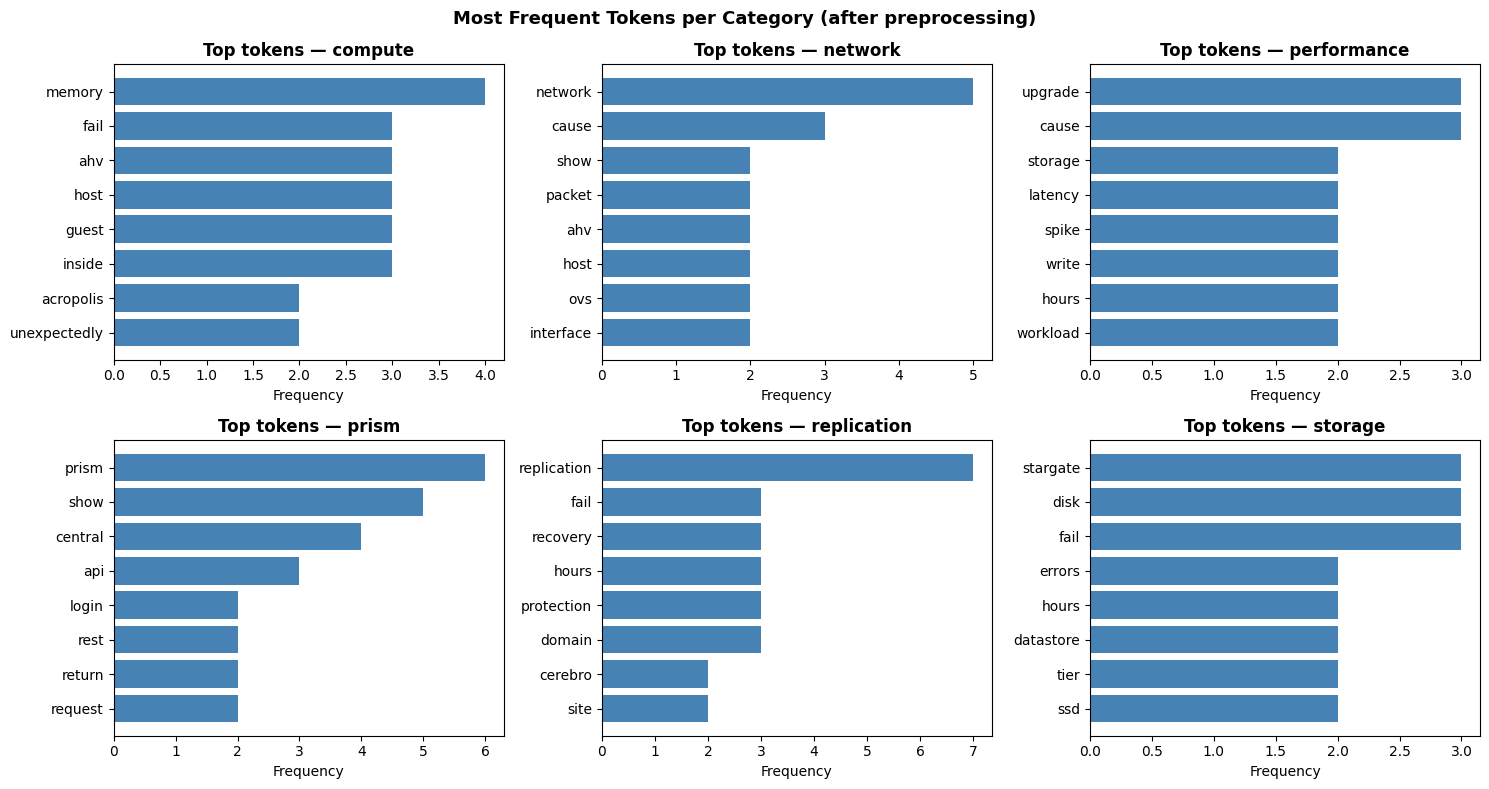

Chart saved: token_frequency.png


In [10]:
from collections import Counter
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, cat in enumerate(sorted(df['category'].unique())):
    cat_text = ' '.join(df[df['category'] == cat]['clean_text'])
    counts = Counter(cat_text.split()).most_common(8)
    words, freqs = zip(*counts)
    axes[i].barh(words[::-1], freqs[::-1], color='steelblue')
    axes[i].set_title(f'Top tokens — {cat}', fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.suptitle('Most Frequent Tokens per Category (after preprocessing)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('token_frequency.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved: token_frequency.png')

## 10. Save Preprocessed Dataset for Lab 4.2

In [11]:
output_path = 'tickets_preprocessed.csv'
df[['text', 'clean_text', 'category']].to_csv(output_path, index=False)
print(f'✅ Saved {len(df)} preprocessed tickets → {output_path}')
print(f'   Columns: text (raw), clean_text (preprocessed), category (label)')

✅ Saved 60 preprocessed tickets → tickets_preprocessed.csv
   Columns: text (raw), clean_text (preprocessed), category (label)


## 11. Lab Summary

| Step | Tool | Purpose |
|------|------|---------|
| Tokenisation | `nltk.word_tokenize` | Split text into tokens, handle punctuation |
| Lowercase | `str.lower()` | Collapse capitalisation variants |
| Alpha filter | `re.match` | Remove numbers, punctuation, hyphenated noise |
| Stop words | `nltk.stopwords` + domain list | Remove high-frequency, low-signal tokens |
| Lemmatisation | `WordNetLemmatizer` | Normalise morphological variants to base form |
| Min length | `len(t) >= 3` | Drop residual short tokens |

**Files produced:**
- `tickets_preprocessed.csv` — cleaned ticket dataset for Lab 4.2
- `token_frequency.png` — per-category vocabulary chart

> **Instructor Note:** In Lab 4.2 we load this CSV and explore how different text representation schemes (BoW, TF-IDF, embeddings) capture the semantic differences between categories.

---
## 🎯 Challenges

### Challenge 1
The current preprocessing removes all numeric tokens. Modify `preprocess()` to also keep **numeric tokens that are 3+ digits** (e.g., `502`, `6000` are meaningful in tickets). Compare the vocabulary size before and after this change.

### Challenge 2
Add a **bigram** extraction step after lemmatisation — capture two-word phrases like `stargate crash`, `live migration`, `prism central`. Use `nltk.bigrams()`. Print the top 5 bigrams per category.

### Challenge 3
The domain stop word list removes `vm` and `error`. Are these the right words to remove? For each category, check whether removing vs retaining these words changes which terms are most frequent. Justify your decision.

In [12]:
# Challenge workspace
